In [ ]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

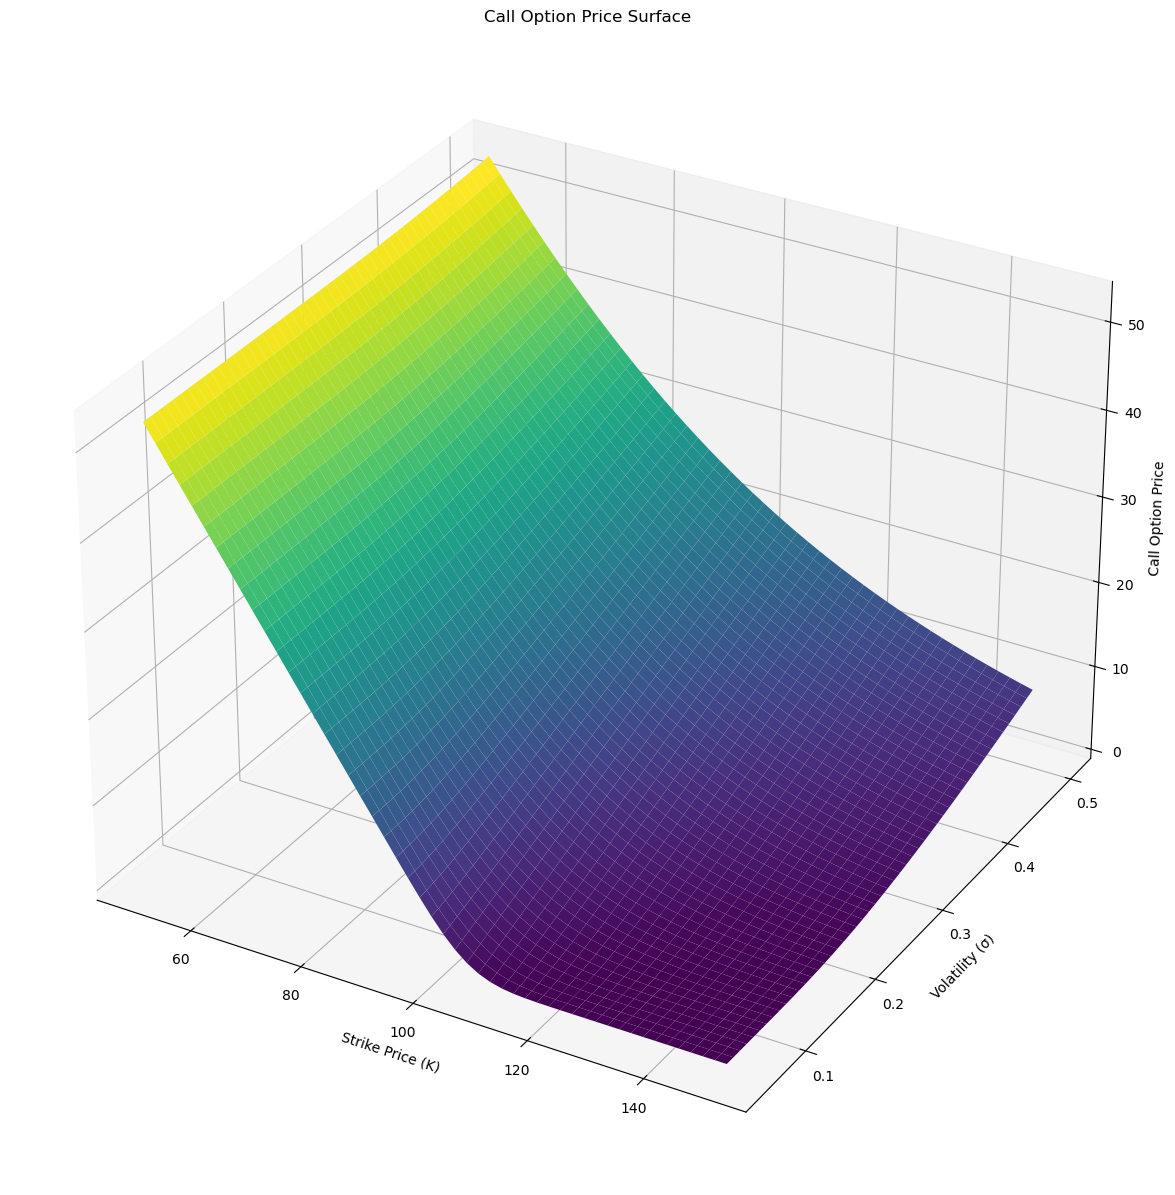

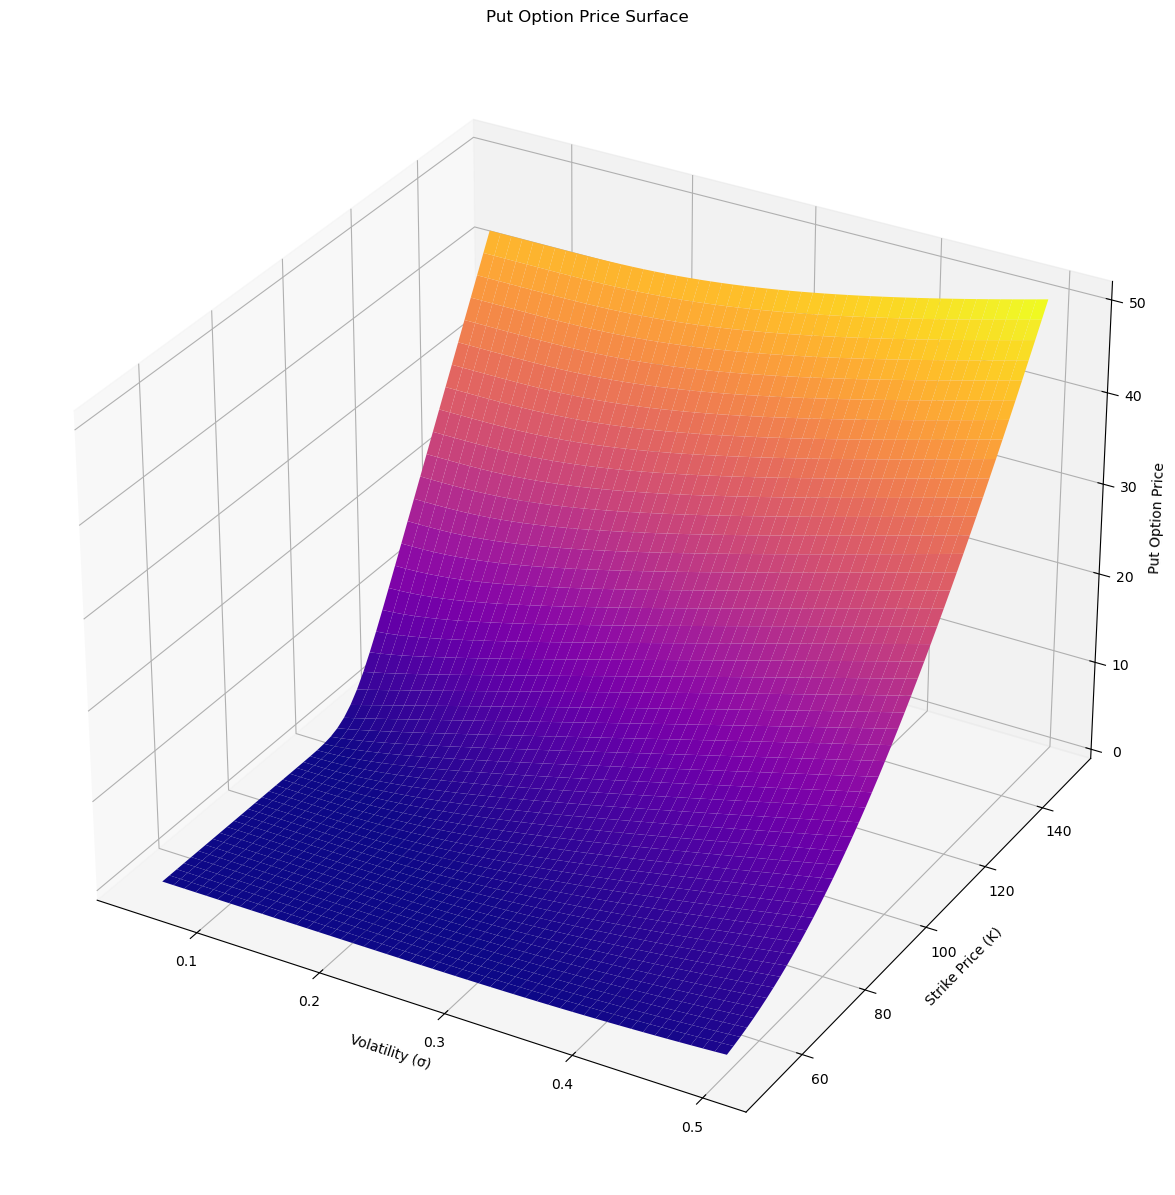

In [95]:

class BlackScholesModel:
    def __init__(self, S, K, T, r, sigma):
        self.S = S
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma

    def d1(self):
        return (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
    
    def d2(self):
        return self.d1() - self.sigma * np.sqrt(self.T)
    
    def call_option_price(self):
        return self.S * si.norm.cdf(self.d1()) - self.K * np.exp(-self.r * self.T) * si.norm.cdf(self.d2())
    
    def put_option_price(self):
        return self.K * np.exp(-self.r * self.T) * si.norm.cdf(-self.d2()) - self.S * si.norm.cdf(-self.d1())

#input parameters
S = 100 #current price
T = 1 #time period
r = 0.05 #interest rate
K_vals = np.linspace(50, 150, 50) #strike price
sigma_vals = np.linspace(0.05, 0.5, 50) #volatitly

K_grid, sigma_grid = np.meshgrid(K_vals, sigma_vals)
call_prices = np.zeros_like(K_grid)
put_prices = np.zeros_like(K_grid)

# Fill in option prices
for i in range(K_grid.shape[0]):
    for j in range(K_grid.shape[1]):
        model = BlackScholesModel(S, K_grid[i, j], T, r, sigma_grid[i, j])
        call_prices[i, j] = model.call_option_price()
        put_prices[i, j] = model.put_option_price()

# --- Separate Plot for Call Options ---
fig_call = plt.figure(figsize=(15, 15))
ax_call = fig_call.add_subplot(111, projection='3d')
ax_call.plot_surface(K_grid, sigma_grid, call_prices, cmap='viridis')
ax_call.set_title('Call Option Price Surface')
ax_call.set_xlabel('Strike Price (K)')
ax_call.set_ylabel('Volatility (σ)')
ax_call.set_zlabel('Call Option Price')
plt.show()

# --- Separate Plot for Put Options ---
fig_put = plt.figure(figsize=(15, 15))
ax_put = fig_put.add_subplot(111, projection='3d')
ax_put.plot_surface(sigma_grid, K_grid, put_prices, cmap='plasma')
ax_put.set_title('Put Option Price Surface')
ax_put.set_ylabel('Strike Price (K)')
ax_put.set_xlabel('Volatility (σ)')
ax_put.set_zlabel('Put Option Price')
plt.show()

In [96]:
# Example: Get call and put price at K = 120, sigma = 0.3
target_K = 100
target_sigma = 0.2

model = BlackScholesModel(S=100, K=target_K, T=1, r=0.05, sigma=target_sigma)
call_price = model.call_option_price()
put_price = model.put_option_price()

print(f"Call Option Price at K={target_K}, σ={target_sigma}: {call_price}")
print(f"Put Option Price at K={target_K}, σ={target_sigma}: {put_price}")

Call Option Price at K=100, σ=0.2: 10.450583572185565
Put Option Price at K=100, σ=0.2: 5.573526022256971
